# Company reviews and reported salaries (India-focused listings)

Dataset: [hardikchoudharyhc/company-reviews-salaries-location-dataset](https://www.kaggle.com/datasets/hardikchoudharyhc/company-reviews-salaries-location-dataset) — CSV **`company_data.csv`**.

Each row is a **company** with scraped **overall rating**, **sector (`Company_type`)**, **review-count text**, **salary text**, and **`Cities`** (single city label). Counts and pay are stored as short Indian-style strings (`k` / `L` plus plain integers); we parse them to numeric magnitudes for plots and correlations.

In [1]:
!pip install nicaviz

In [2]:
from pathlib import Path
import re

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")


def _distplot_compat(a, ax=None, **kwargs):
    """Seaborn ≥0.12 removed `sns.distplot`; nicaviz still calls it internally."""
    kde_kws = kwargs.pop("kde_kws", {}) or {}
    if ax is None:
        ax = plt.gca()
    sns.histplot(a, ax=ax, kde=True, stat="density", kde_kws=kde_kws, **kwargs)
    return ax


if not hasattr(sns, "distplot"):
    sns.distplot = _distplot_compat

import nicaviz  # noqa: F401 — registers `DataFrame.nica` accessor


## Load data

On Kaggle, mirror this dataset under **`/kaggle/input/…`**. Locally, **`kagglehub.dataset_download`** caches files under your user directory (or use a checked-in copy under **`eda/data/company_data.csv`**).


In [3]:
CSV_NAME = "company_data.csv"

# Download latest version
path = kagglehub.dataset_download("hardikchoudharyhc/company-reviews-salaries-location-dataset")
print("Path to dataset files:", path)


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        named = sorted(kaggle_root.rglob(CSV_NAME), key=lambda p: p.stat().st_size, reverse=True)
        if named:
            return named[0]
        any_csv = list(kaggle_root.rglob("*.csv"))
        if any_csv:
            return max(any_csv, key=lambda p: p.stat().st_size)
        raise FileNotFoundError(f"No CSV under {kaggle_root}")

    local = Path("data") / CSV_NAME
    if local.exists():
        return local.resolve()

    root = Path(path)
    nested = list(root.glob(f"**/{CSV_NAME}"))
    if nested:
        return nested[0]

    csvs = list(root.rglob("*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No CSV under kagglehub path {root}")
    return max(csvs, key=lambda p: p.stat().st_size)


csv_path = resolve_csv_path()
print("CSV:", csv_path)

raw = pd.read_csv(csv_path, low_memory=False)
print(raw.shape[0], "rows ×", raw.shape[1], "cols")


Path to dataset files: /kaggle/input/datasets/hardikchoudharyhc/company-reviews-salaries-location-dataset
CSV: /kaggle/input/datasets/hardikchoudharyhc/company-reviews-salaries-location-dataset/company_data.csv
9978 rows × 6 cols


## First look

Random sample, dtypes, and a **numeric `describe`** after parsing review and salary strings (`k` → ×1e3, `L` → ×1e5, bare integers preserved). **`company_type_top`** and **`city_top`** bucket long tails so bar and heatmap panels stay readable.


In [4]:

def parse_compact_indian_count(raw):
    """Map strings like '9.9L Salaries', '72k Reviews', or '999 Reviews' to a float magnitude."""
    if pd.isna(raw):
        return np.nan
    s = str(raw).strip().replace(",", "")
    if s in ("--", "-", "", "nan") or s.startswith("--"):
        return np.nan
    m = re.match(r"^([\d.]+)\s*([kKlL])\b", s)
    if m:
        val = float(m.group(1))
        unit = m.group(2).lower()
        if unit == "l":
            return val * 100_000.0
        return val * 1_000.0
    m2 = re.match(r"^([\d.]+)\s*(?:Reviews|Salaries)?\s*$", s, re.I)
    if m2:
        return float(m2.group(1))
    return np.nan


def top_bucket(series: pd.Series, n: int, other: str = "Other") -> pd.Series:
    keep = set(series.value_counts().index[:n])
    return series.where(series.isin(keep), other)


df = raw.copy()
df["reviews_parsed"] = df["Reviews"].map(parse_compact_indian_count)
df["salary_parsed"] = df["Salaries"].map(parse_compact_indian_count)

df["company_type_top"] = top_bucket(df["Company_type"], n=8)
df["city_top"] = top_bucket(df["Cities"], n=12)

CAT_COLS = ["company_type_top", "city_top"]
ID_LIKE = ["Name", "Company_type", "Cities", "Reviews", "Salaries"]
NUM_COLS = ["Rating", "reviews_parsed", "salary_parsed"]

display(df.sample(5, random_state=42))
display(df.dtypes.to_frame("dtype"))
display(df[NUM_COLS].describe().T)


,Name,Rating,Company_type,Reviews,Salaries,Cities,reviews_parsed,salary_parsed,company_type_top,city_top
5753,HeyCoach,4.0,Education & Training,190 Reviews,188 Salaries,Bengaluru,190.0,188.0,Education & Training,Bengaluru
7623,Nirmal Industrial Controls,3.7,Industrial Automation,143 Reviews,759 Salaries,Mumbai,143.0,759.0,Other,Mumbai
6393,NaviSite,3.9,IT Services & Consulting,170 Reviews,1.4k Salaries,Gurugram,170.0,1400.0,IT Services & Consulting,Gurugram
107,Siemens,3.9,Industrial Automation,5.7k Reviews,33.9k Salaries,Bengaluru,5700.0,33900.0,Other,Bengaluru
3422,Greentech Industries,3.8,Industrial Machinery,318 Reviews,1.1k Salaries,Nellore,318.0,1100.0,Industrial Machinery,Other


,dtype
Name,object
Rating,float64
Company_type,object
Reviews,object
Salaries,object
Cities,object
reviews_parsed,float64
salary_parsed,float64
company_type_top,object
city_top,object


,count,mean,std,min,25%,50%,75%,max
Rating,9978.0,3.737994,0.417403,1.0,3.5,3.8,4.0,4.9
reviews_parsed,9978.0,615.208358,2464.497854,107.0,146.0,218.0,429.0,110000.0
salary_parsed,9974.0,2741.633246,18090.368256,2.0,551.0,881.0,1700.0,990000.0


### Categorical snapshot (`nica.categorical_describe`)

Bucketing keeps **`company_type_top`** and **`city_top`** at sizes comparable to the Costa Rica notebook’s region / income facets.


In [5]:
display(df[CAT_COLS].nica.categorical_describe())


Dataframe Dimension: 9978 Rows, 2 Columns


,Unique,Missing,dtype,ValCount 1,Occ,ValCount 2,Occ,ValCount 3,Occ,ValCount 4,Occ,ValCount 5,Occ
Column,,,,,,,,,,,,,
company_type_top,9,0,object,Other,6036,IT Services & Consulting,1306,Engineering & Construction,480,Auto Components,432,Pharma,397
city_top,13,0,object,Other,2026,Mumbai,1509,Bengaluru,1444,New Delhi,845,Pune,771


## Univariate analysis

- **Categorical:** horizontal count plots (via **`mass_plot` / `countplot`**) so city and sector labels stay readable.
- **Continuous:** two `catplot(kind="box")` sweeps (hue by **`company_type_top`**, then separately by **`city_top`**) across all numeric fields in a wrap grid with **per-variable y-scales** (`sharey=False`) so **rating**, **review counts**, and **parsed salary magnitudes** don’t flatten each other—the same “show every distribution with facets” sweep as the Costa Rica notebook.


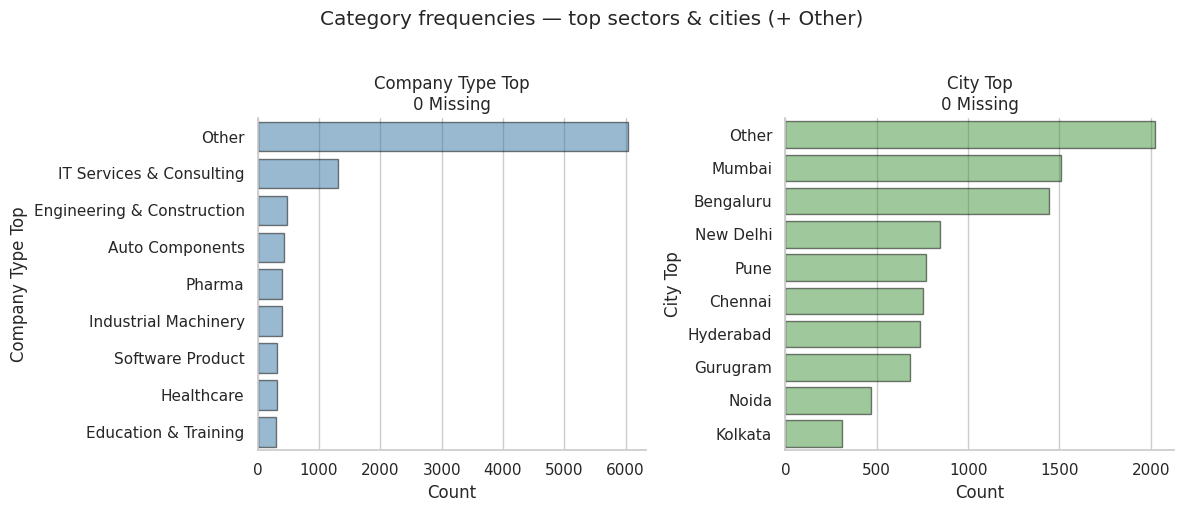

In [6]:
fig = df.nica.mass_plot(CAT_COLS, "countplot", columns=2, figsize=(12, 5))
fig.suptitle("Category frequencies — top sectors & cities (+ Other)", y=1.02)
plt.tight_layout()
plt.show()


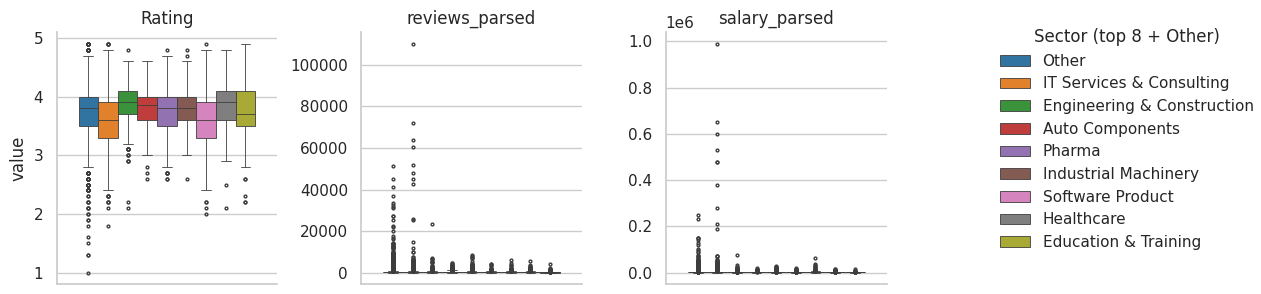

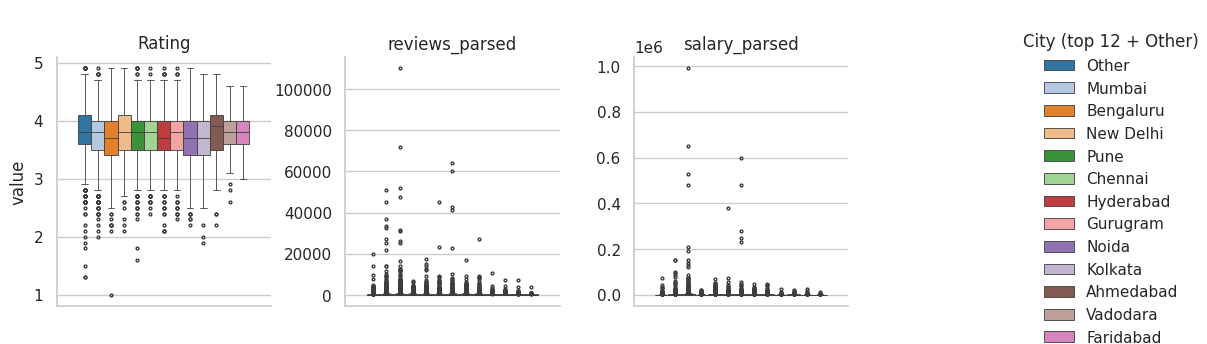

In [7]:
long = df.melt(
    id_vars=CAT_COLS,
    value_vars=NUM_COLS,
    var_name="variable",
    value_name="value",
)

hue_order_sector = list(df["company_type_top"].value_counts().index)
g_sec = sns.catplot(
    data=long,
    y="value",
    col="variable",
    hue="company_type_top",
    hue_order=hue_order_sector,
    kind="box",
    col_wrap=3,
    sharey=False,
    height=3.1,
    aspect=1.05,
    linewidth=0.6,
    fliersize=2,
    dodge=True,
    palette="tab10",
)
g_sec.set_axis_labels("", "value")
g_sec.set_titles("{col_name}")
if g_sec._legend is not None:
    g_sec._legend.set_title("Sector (top 8 + Other)")
    g_sec._legend.set_bbox_to_anchor((1.02, 0.5))
g_sec.tight_layout()
plt.subplots_adjust(right=0.72)
plt.show()

hue_order_city = list(df["city_top"].value_counts().index)
g_city = sns.catplot(
    data=long,
    y="value",
    col="variable",
    hue="city_top",
    hue_order=hue_order_city,
    kind="box",
    col_wrap=3,
    sharey=False,
    height=3.1,
    aspect=1.12,
    linewidth=0.6,
    fliersize=2,
    dodge=True,
    palette="tab20",
)
g_city.set_axis_labels("", "value")
g_city.set_titles("{col_name}")
if g_city._legend is not None:
    g_city._legend.set_title("City (top 12 + Other)")
    g_city._legend.set_bbox_to_anchor((1.02, 0.5))
g_city.tight_layout()
plt.subplots_adjust(right=0.72)
plt.show()


### Univariate reflection

- **Sectors and cities** are heavy-tailed (a few IT / consulting giants and metro hubs dominate raw counts), so pair the frequency bars with **row-normalised** heatmaps below; the two hue-stratified box sweeps show how those buckets separate on **rating**, **reviews**, and **parsed salary** within each facet.
- **Parsed salaries** inherit site-specific string formatting; treat them as **ordinal / heuristic magnitudes**, not verified compensation.
- **Ratings** sit on a narrow 1–5 scale while review volume spans orders of magnitude—`sharey=False` keeps each marginal readable.


## Multivariate analysis

1. **Correlation matrix** — how **rating**, **review volume**, and **parsed salary text** co-vary.
2. **`rank_correlations_plots`** — strongest pairwise trends with an ordered polynomial guide (same nicaviz tour as Costa Rica).
3. **`lmplot`** — **rating vs parsed salary**, coloured by **`company_type_top`**.
4. **Box / violin** — **rating** and **log₁₀(reviews + 1)** across **`company_type_top`**.
5. **Two-way categorical** — **`company_type_top` × `city_top`** composition plus **`pivot_plots`** for mean **rating**.


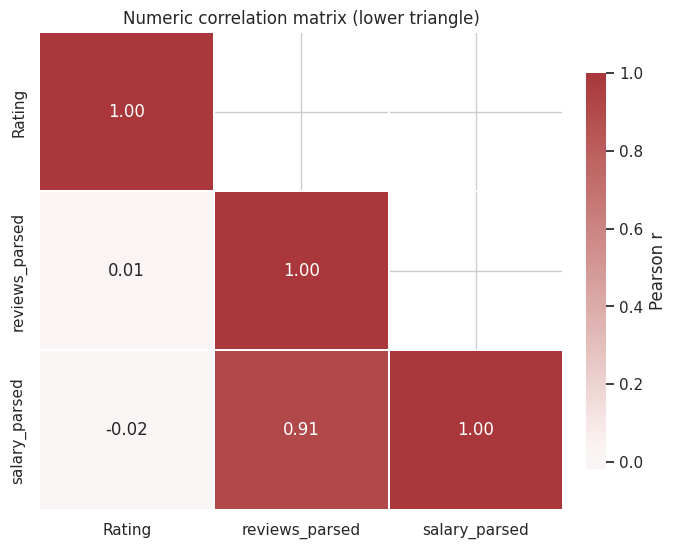

In [8]:
cm = df[NUM_COLS].corr()
mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(7.5, 6.2))
sns.heatmap(
    cm,
    mask=mask,
    cmap="vlag",
    center=0,
    linewidths=0.3,
    ax=ax,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Pearson r", "fraction": 0.035, "pad": 0.04},
)
ax.set_title("Numeric correlation matrix (lower triangle)")
plt.subplots_adjust(right=0.88)
plt.show()


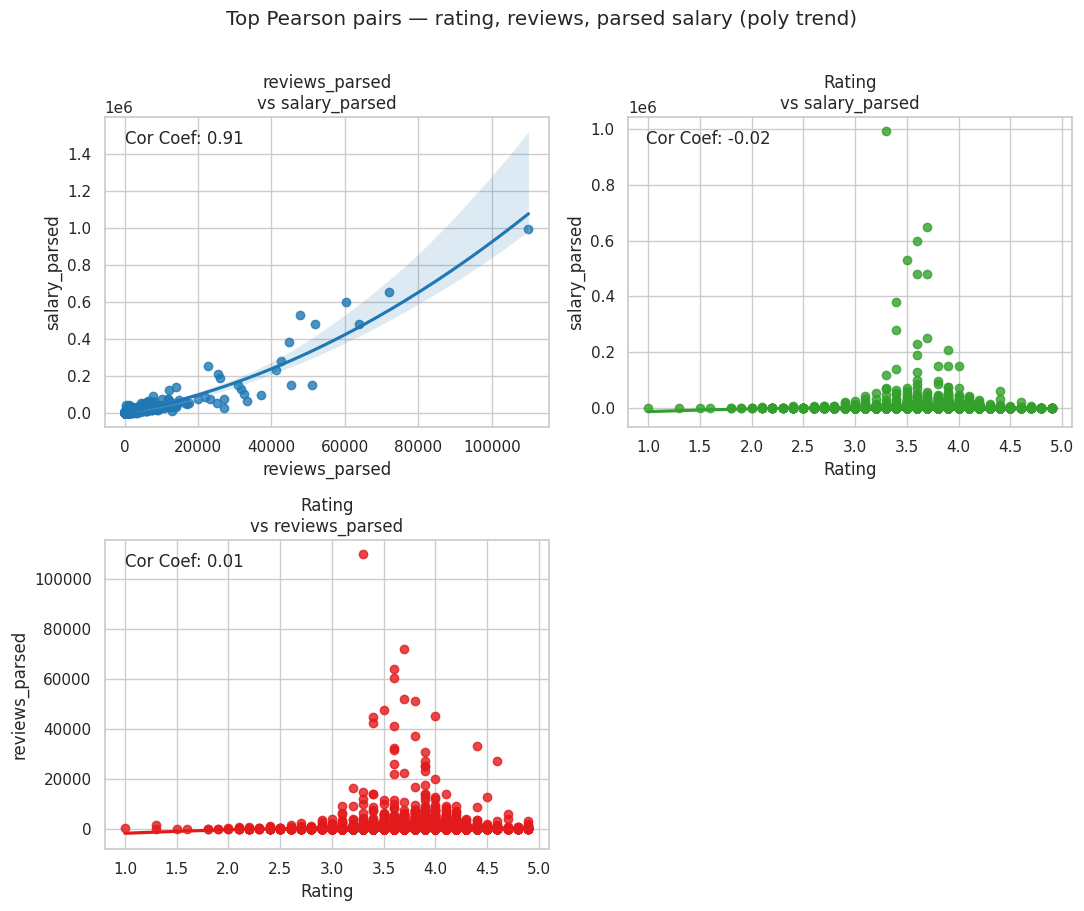

In [9]:
fig = df.nica.rank_correlations_plots(NUM_COLS, n=4, columns=2, polyorder=2, figsize=(11, 9))
fig.suptitle("Top Pearson pairs — rating, reviews, parsed salary (poly trend)", y=1.01)
plt.tight_layout()
plt.show()


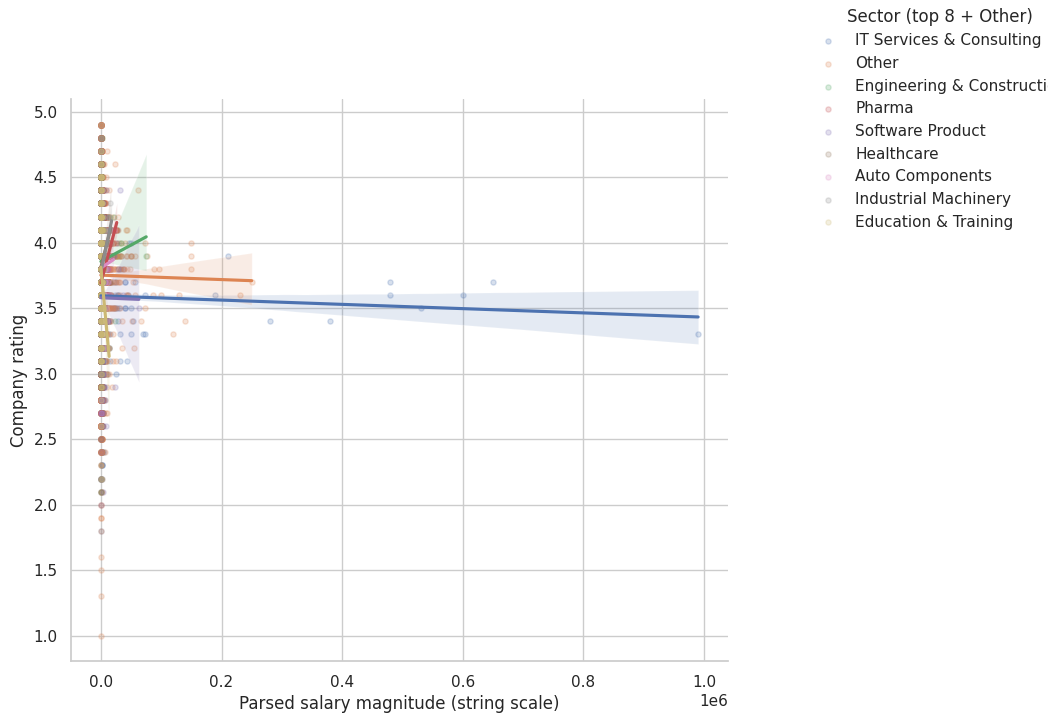

In [10]:
plot_df = df.dropna(subset=["salary_parsed"]).copy()
g = sns.lmplot(
    data=plot_df,
    x="salary_parsed",
    y="Rating",
    hue="company_type_top",
    scatter_kws={"alpha": 0.22, "s": 14},
    height=6.5,
    aspect=1.22,
    lowess=False,
)
g.set_axis_labels("Parsed salary magnitude (string scale)", "Company rating")
if g._legend is not None:
    g._legend.set_title("Sector (top 8 + Other)")
    g._legend.set_bbox_to_anchor((1.02, 0.93))
plt.subplots_adjust(right=0.72)
plt.show()


/tmp/ipykernel_16/1659528935.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="company_type_top", y="Rating", ax=axes[0], palette="muted")
/tmp/ipykernel_16/1659528935.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="company_type_top", y="log_reviews", ax=axes[1], palette="muted", inner="quart")


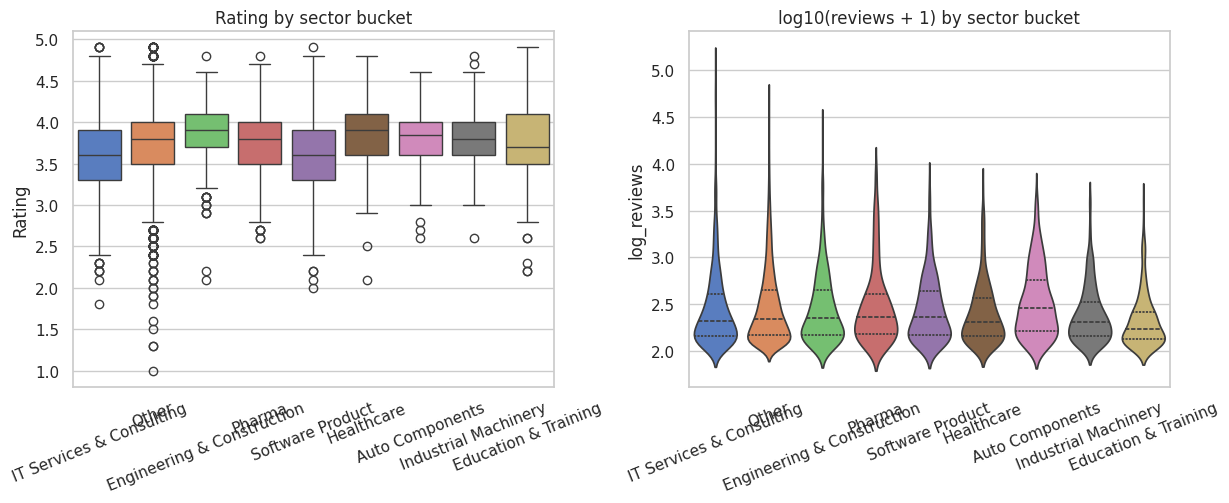

In [11]:
df["log_reviews"] = np.log10(df["reviews_parsed"] + 1.0)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
sns.boxplot(data=df, x="company_type_top", y="Rating", ax=axes[0], palette="muted")
axes[0].set_title("Rating by sector bucket")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=22)

sns.violinplot(data=df, x="company_type_top", y="log_reviews", ax=axes[1], palette="muted", inner="quart")
axes[1].set_title("log10(reviews + 1) by sector bucket")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=22)

plt.tight_layout()
plt.show()


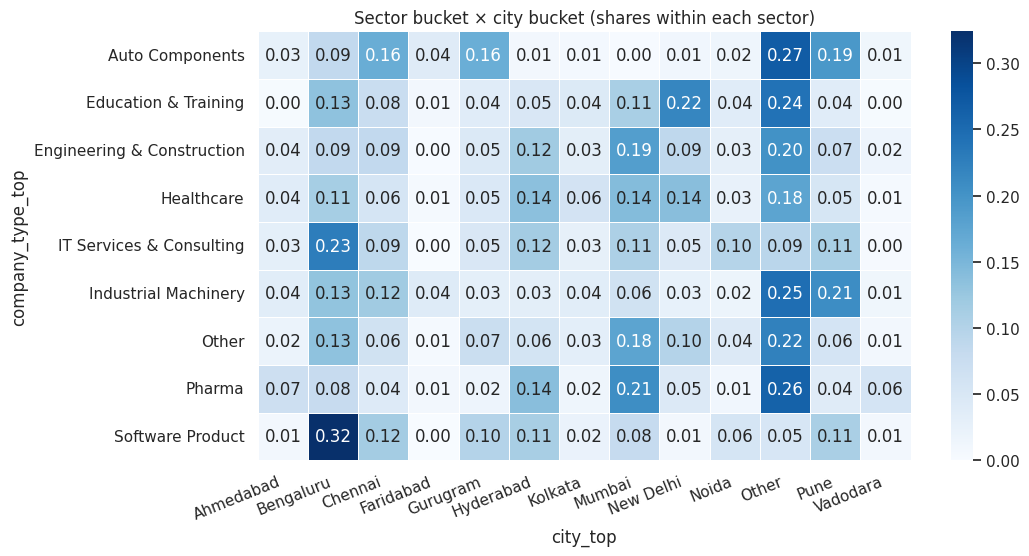

In [12]:
ct = pd.crosstab(df["company_type_top"], df["city_top"], normalize="index")
fig, ax = plt.subplots(figsize=(12.0, 6.5))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", linewidths=0.4, ax=ax)
ax.set_title("Sector bucket × city bucket (shares within each sector)")
ax.set_ylabel("company_type_top")
plt.xticks(rotation=22, ha="right")
plt.subplots_adjust(bottom=0.22, left=0.24, right=0.92)
plt.show()


/usr/local/lib/python3.12/dist-packages/nicaviz/dataframe_visualizer.py:396: FutureWarning: The provided callable <function mean at 0x7b9ad4f991c0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = pd.pivot_table(


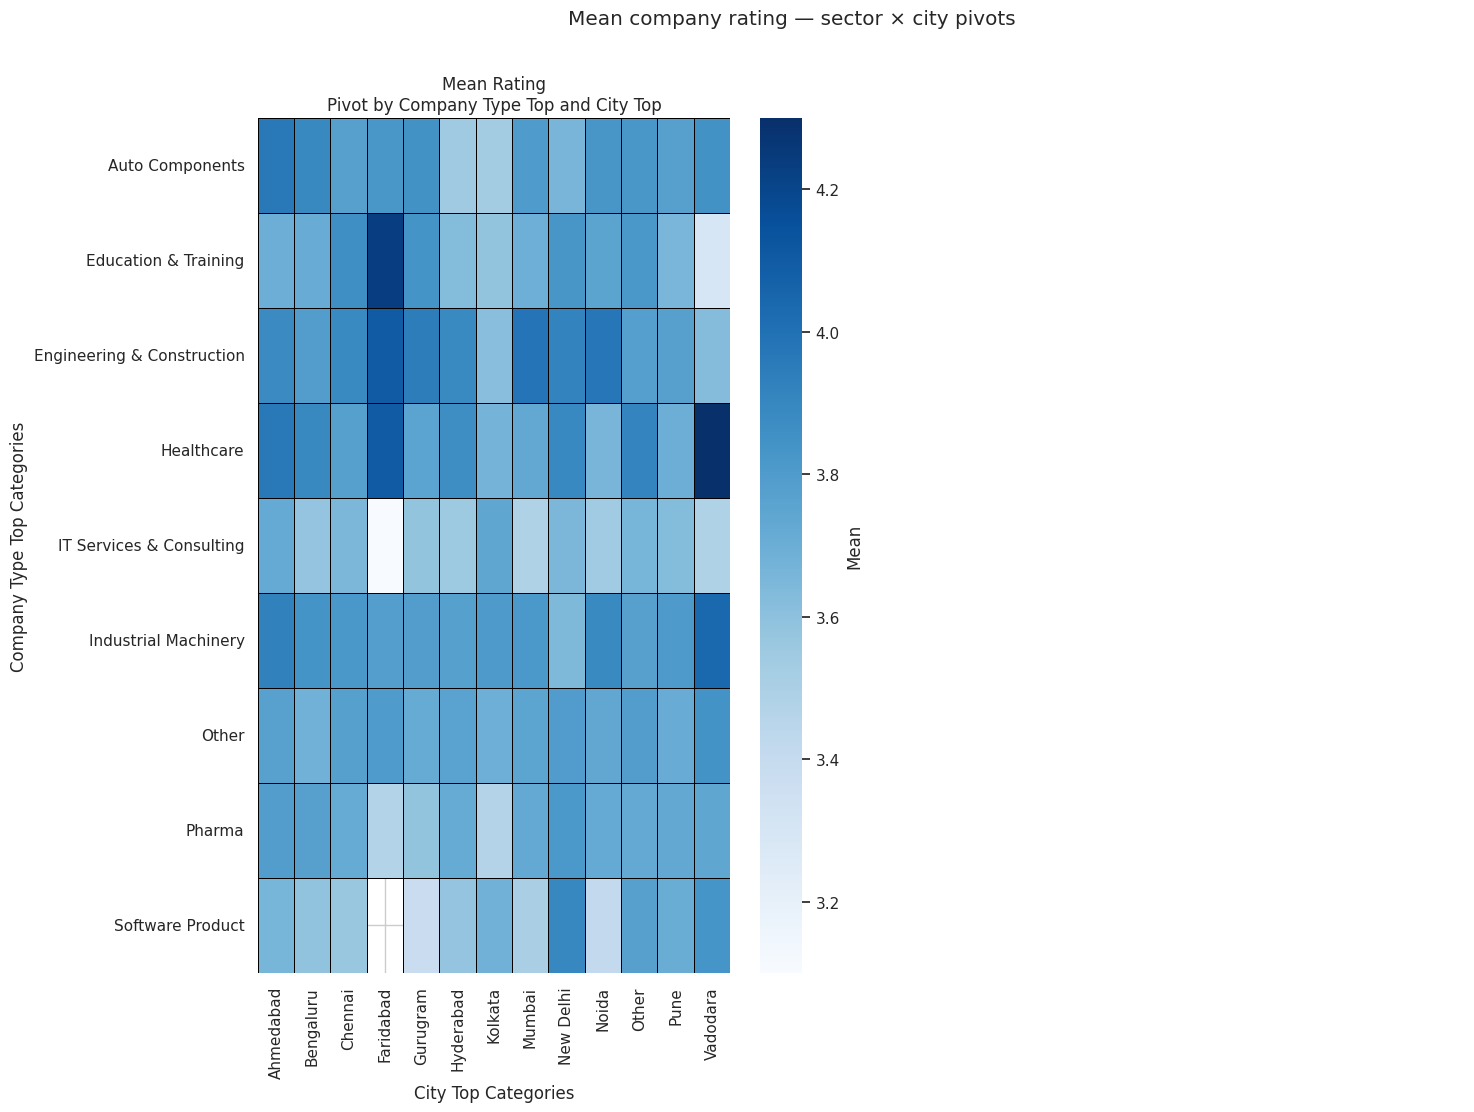

In [13]:
p_df = df[["company_type_top", "city_top", "Rating"]].copy()
fig = p_df.nica.pivot_plots(
    ["company_type_top", "city_top"],
    "Rating",
    np.mean,
    columns=2,
    figsize=(16, 11),
)
fig.suptitle("Mean company rating — sector × city pivots", y=1.01)
plt.tight_layout()
plt.subplots_adjust(right=0.92)
plt.show()


### Synthesis

**Distributions:** sector and city buckets mirror the long tail of the Indian job-board graph—frequencies are intentionally **imbalanced**, so lean on **normalised** cross-tabs when comparing composition.

**Correlations:** the heatmap plus **`nica.rank_correlations_plots`** flags which **parsed listing fields move together**; remember **scraping artifacts** (e.g., missing salary tokens) can tighten or dilute correlations.

**Strata:** **`company_type_top`** overlays separate **rating–salary** clouds the marginals hide, and the **sector × city** tables highlight **where** certain industries concentrate in this snapshot.
